### Import Library

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

%matplotlib inline

In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ML/dataset_sdn.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,...,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,1.010000e+11,3,...,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2.810000e+11,2,...,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,3,3413,3665,0,0.0,0.0,0


### Pemrosesan Data

#### Pengecekan baris dan kolom

In [4]:
print("This Dataset has {} rows and {} columns".format(df.shape[0], df.shape[1]))

This Dataset has 104345 rows and 23 columns


#### Menunjukan Type data dari kolom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104345 entries, 0 to 104344
Data columns (total 23 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   dt           104345 non-null  int64  
 1   switch       104345 non-null  int64  
 2   src          104345 non-null  object 
 3   dst          104345 non-null  object 
 4   pktcount     104345 non-null  int64  
 5   bytecount    104345 non-null  int64  
 6   dur          104345 non-null  int64  
 7   dur_nsec     104345 non-null  int64  
 8   tot_dur      104345 non-null  float64
 9   flows        104345 non-null  int64  
 10  packetins    104345 non-null  int64  
 11  pktperflow   104345 non-null  int64  
 12  byteperflow  104345 non-null  int64  
 13  pktrate      104345 non-null  int64  
 14  Pairflow     104345 non-null  int64  
 15  Protocol     104345 non-null  object 
 16  port_no      104345 non-null  int64  
 17  tx_bytes     104345 non-null  int64  
 18  rx_bytes     104345 non-

#### Nilai statistik dataset

In [6]:
df.describe()

,dt,switch,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,packetins,pktperflow,byteperflow,pktrate,Pairflow,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
count,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000,1.043450e+05,1.043450e+05,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000,104345.000000,104345.000000,1.043450e+05,1.043450e+05,104345.000000,103839.000000,103839.000000,104345.000000
mean,17927.514169,4.214260,52860.954746,3.818660e+07,321.497398,4.613880e+08,3.218865e+11,5.654234,5200.383468,6381.715291,4.716150e+06,212.210676,0.600987,2.331094,9.325264e+07,9.328039e+07,998.899756,1003.811420,2007.578742,0.390857
std,11977.642655,1.956327,52023.241460,4.877748e+07,283.518232,2.770019e+08,2.834029e+11,2.950036,5257.001450,7404.777808,7.560116e+06,246.855123,0.489698,1.084333,1.519380e+08,1.330004e+08,2423.471618,2054.887034,3144.437173,0.487945
min,2488.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,2.000000,4.000000,-130933.000000,-1.464426e+08,-4365.000000,0.000000,1.000000,2.527000e+03,8.560000e+02,0.000000,0.000000,0.000000,0.000000
25%,7098.000000,3.000000,808.000000,7.957600e+04,127.000000,2.340000e+08,1.270000e+11,3.000000,1943.000000,29.000000,2.842000e+03,0.000000,0.000000,1.000000,4.743000e+03,3.539000e+03,0.000000,0.000000,0.000000,0.000000
50%,11905.000000,4.000000,42828.000000,6.471930e+06,251.000000,4.180000e+08,2.520000e+11,5.000000,3024.000000,8305.000000,5.521680e+05,276.000000,1.000000,2.000000,4.219610e+06,1.338339e+07,0.000000,0.000000,4.000000,0.000000
75%,29952.000000,5.000000,94796.000000,7.620354e+07,412.000000,7.030000e+08,4.130000e+11,7.000000,7462.000000,10017.000000,9.728112e+06,333.000000,1.000000,3.000000,1.356398e+08,1.439277e+08,251.000000,557.000000,3838.000000,1.000000
max,42935.000000,10.000000,260006.000000,1.471280e+08,1881.000000,9.990000e+08,1.880000e+12,17.000000,25224.000000,19190.000000,1.495387e+07,639.000000,1.000000,5.000000,1.269982e+09,9.905962e+08,20580.000000,16577.000000,20580.000000,1.000000


#### heatmap Nilai yang hilang

<Axes: >

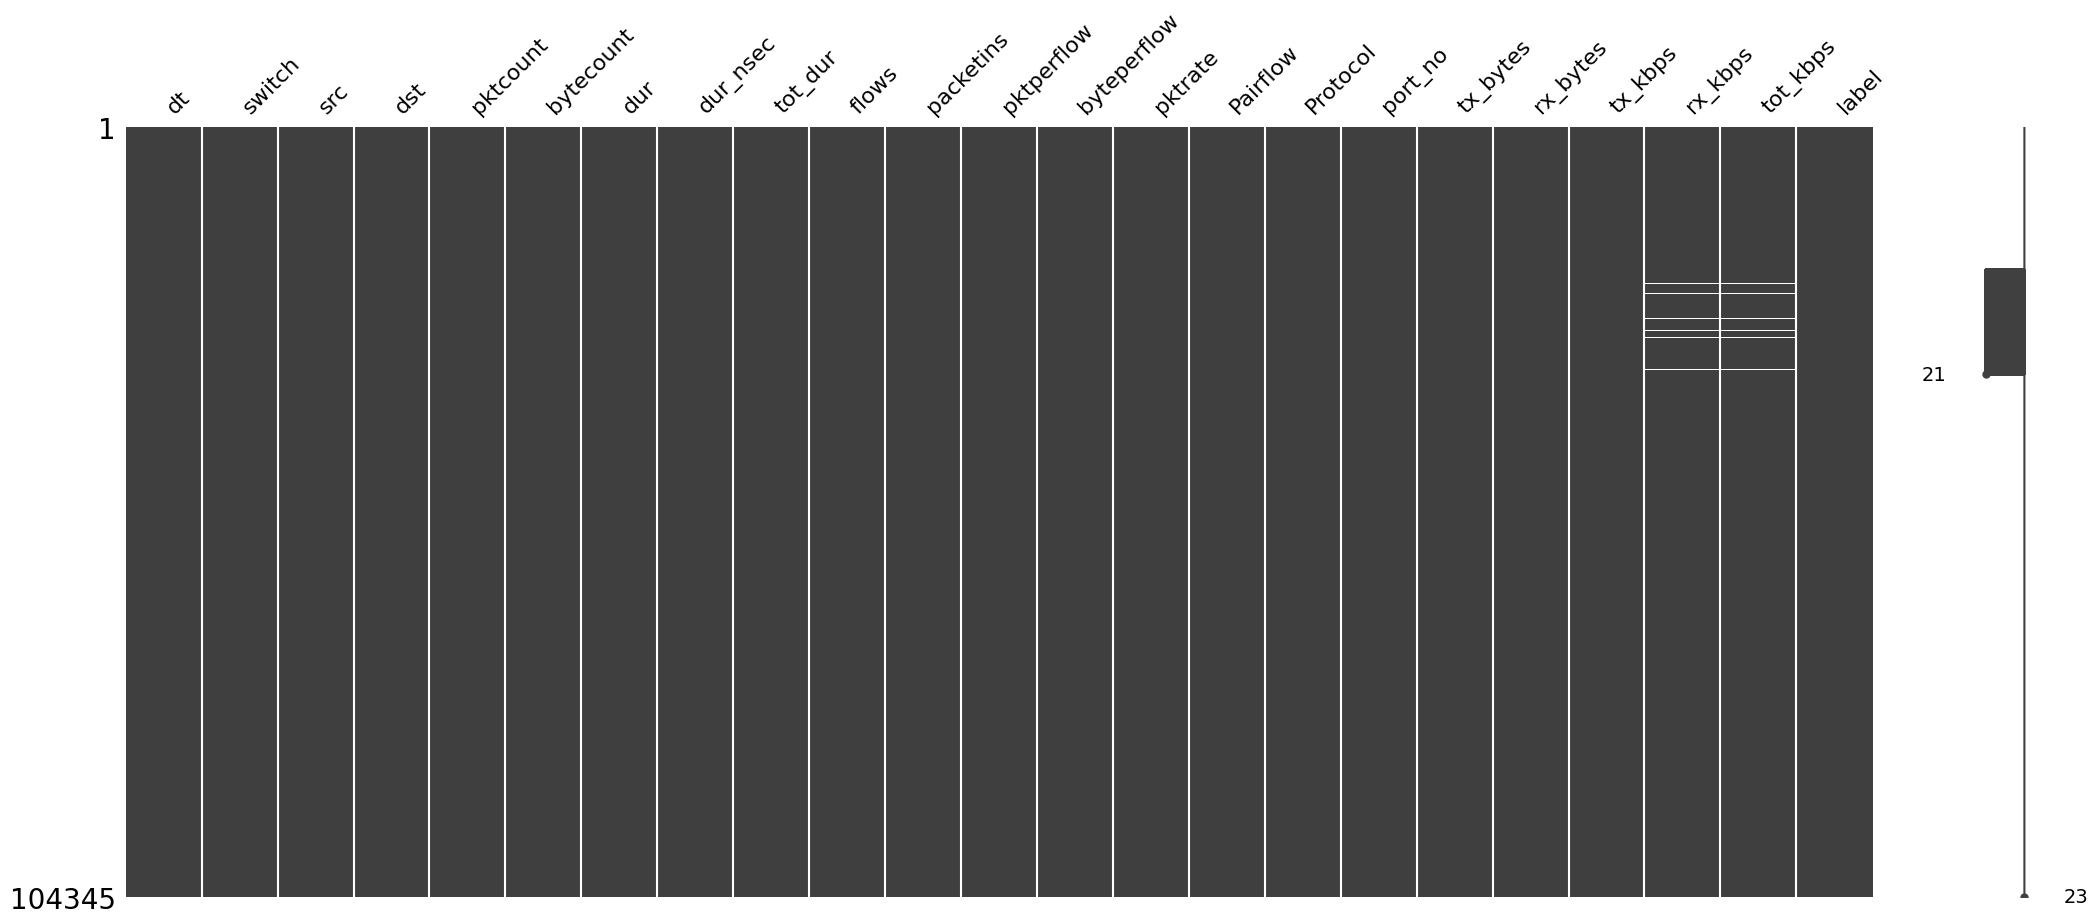

In [7]:
msno.matrix(df)

#### Menghitung nilai kosong dari fitur

In [8]:
df.isnull().sum()

,0
dt,0
switch,0
src,0
dst,0
pktcount,0
bytecount,0
dur,0
dur_nsec,0
tot_dur,0
flows,0


In [9]:
(df.isnull().sum()/df.isnull().count())*100

,0
dt,0.00000
switch,0.00000
src,0.00000
dst,0.00000
pktcount,0.00000
bytecount,0.00000
dur,0.00000
dur_nsec,0.00000
tot_dur,0.00000
flows,0.00000


#### Menghapus kolom dengan nilai null

In [10]:
df.dropna(inplace=True)

#### Pengecekan nilai null

In [11]:
print(df.isnull().sum())
print("This Dataframe has {} rows and {} columns after removing null values".format(df.shape[0], df.shape[1]))

dt             0
switch         0
src            0
dst            0
pktcount       0
bytecount      0
dur            0
dur_nsec       0
tot_dur        0
flows          0
packetins      0
pktperflow     0
byteperflow    0
pktrate        0
Pairflow       0
Protocol       0
port_no        0
tx_bytes       0
rx_bytes       0
tx_kbps        0
rx_kbps        0
tot_kbps       0
label          0
dtype: int64
This Dataframe has 103839 rows and 23 columns after removing null values


#### distribusi kelas label

In [12]:
malign = df[df['label'] == 1]
benign = df[df['label'] == 0]

print('Number of DDOS attacks that has occured :',round((len(malign)/df.shape[0])*100,2),'%')
print('Number of DDOS attacks that has not occured :',round((len(benign)/df.shape[0])*100,2),'%')

Number of DDOS attacks that has occured : 39.01 %
Number of DDOS attacks that has not occured : 60.99 %


#### Numerical Features

In [13]:
numerical_features = [feature for feature in df.columns if df[feature].dtypes != 'O']
print("The number of numerical features is",len(numerical_features),"and they are : \n",numerical_features)

The number of numerical features is 20 and they are : 
 ['dt', 'switch', 'pktcount', 'bytecount', 'dur', 'dur_nsec', 'tot_dur', 'flows', 'packetins', 'pktperflow', 'byteperflow', 'pktrate', 'Pairflow', 'port_no', 'tx_bytes', 'rx_bytes', 'tx_kbps', 'rx_kbps', 'tot_kbps', 'label']


#### Categorical Features

In [14]:
categorical_features = [feature for feature in df.columns if df[feature].dtypes == 'O']
print("The number of categorical features is",len(categorical_features),"and they are : \n",categorical_features)

The number of categorical features is 3 and they are : 
 ['src', 'dst', 'Protocol']


#### Gabut

In [15]:
# number of unique values in each numerical variable
df[numerical_features].nunique(axis=0)

,0
dt,858
switch,10
pktcount,9044
bytecount,9270
dur,840
dur_nsec,1000
tot_dur,4183
flows,15
packetins,168
pktperflow,2092


#### Ngecek nilai discrete

In [16]:
#discrete numerical features
discrete_feature = [feature for feature in numerical_features if df[feature].nunique()<=15 and feature != 'label']
print("The number of discrete features is",len(discrete_feature),"and they are : \n",discrete_feature)

The number of discrete features is 4 and they are : 
 ['switch', 'flows', 'Pairflow', 'port_no']


In [17]:
df[discrete_feature].head(10)

,switch,flows,Pairflow,port_no
0,1,3,0,3
1,1,2,0,4
2,1,3,0,1
3,1,3,0,2
4,1,3,0,3
5,1,3,0,1
6,1,3,0,4
7,1,3,0,1
8,1,3,0,2
9,1,3,0,4


#### Nilai continuos

In [18]:
continuous_feature=[feature for feature in numerical_features if feature not in discrete_feature + ['label']]
print("The number of continuous_feature features is",len(continuous_feature),"and they are : \n",continuous_feature)

The number of continuous_feature features is 15 and they are : 
 ['dt', 'pktcount', 'bytecount', 'dur', 'dur_nsec', 'tot_dur', 'packetins', 'pktperflow', 'byteperflow', 'pktrate', 'tx_bytes', 'rx_bytes', 'tx_kbps', 'rx_kbps', 'tot_kbps']


### Encoding

In [19]:
df = pd.get_dummies(df, columns=categorical_features,drop_first=True)
print("This Dataframe has {} rows and {} columns after encoding".format(df.shape[0], df.shape[1]))

This Dataframe has 103839 rows and 57 columns after encoding


In [20]:
#dataframe after encoding
df.head(10)

,dt,switch,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,packetins,pktperflow,...,dst_10.0.0.2,dst_10.0.0.3,dst_10.0.0.4,dst_10.0.0.5,dst_10.0.0.6,dst_10.0.0.7,dst_10.0.0.8,dst_10.0.0.9,Protocol_TCP,Protocol_UDP
0,11425,1,45304,48294064,100,716000000,1.010000e+11,3,1943,13535,...,False,False,False,False,False,False,True,False,False,True
1,11605,1,126395,134737070,280,734000000,2.810000e+11,2,1943,13531,...,False,False,False,False,False,False,True,False,False,True
2,11425,1,90333,96294978,200,744000000,2.010000e+11,3,1943,13534,...,False,False,False,False,False,False,True,False,False,True
3,11425,1,90333,96294978,200,744000000,2.010000e+11,3,1943,13534,...,False,False,False,False,False,False,True,False,False,True
4,11425,1,90333,96294978,200,744000000,2.010000e+11,3,1943,13534,...,False,False,False,False,False,False,True,False,False,True
5,11425,1,90333,96294978,200,744000000,2.010000e+11,3,1943,13534,...,False,False,False,False,False,False,True,False,False,True
6,11425,1,45304,48294064,100,716000000,1.010000e+11,3,1943,13535,...,False,False,False,False,False,False,True,False,False,True
7,11425,1,45304,48294064,100,716000000,1.010000e+11,3,1943,13535,...,False,False,False,False,False,False,True,False,False,True
8,11425,1,45304,48294064,100,716000000,1.010000e+11,3,1943,13535,...,False,False,False,False,False,False,True,False,False,True
9,11425,1,90333,96294978,200,744000000,2.010000e+11,3,1943,13534,...,False,False,False,False,False,False,True,False,False,True


In [21]:
df.dtypes

,0
dt,int64
switch,int64
pktcount,int64
bytecount,int64
dur,int64
dur_nsec,int64
tot_dur,float64
flows,int64
packetins,int64
pktperflow,int64


### Memisahkan label

In [22]:
#separating input and output attributes
x = df.drop(['label'], axis=1)
y = df['label']

### Normalisasi fitur

In [23]:
ms = MinMaxScaler()
x = ms.fit_transform(x)

### Train-Test-Split [70-30]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size=0.3)
print(X_train.shape, X_test.shape)

(72687, 56) (31152, 56)


##Smote

In [25]:
from imblearn.over_sampling import SMOTE
from sklearn import metrics

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Jumlah data sebelum SMOTE: {len(y_train)}")
print(f"Jumlah data setelah SMOTE: {len(y_train_smote)}")

Jumlah data sebelum SMOTE: 72687
Jumlah data setelah SMOTE: 88556


/tmp/ipykernel_7871/3688120484.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_series, ax=axes[0], palette='viridis')
/tmp/ipykernel_7871/3688120484.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote_series, ax=axes[1], palette='viridis')


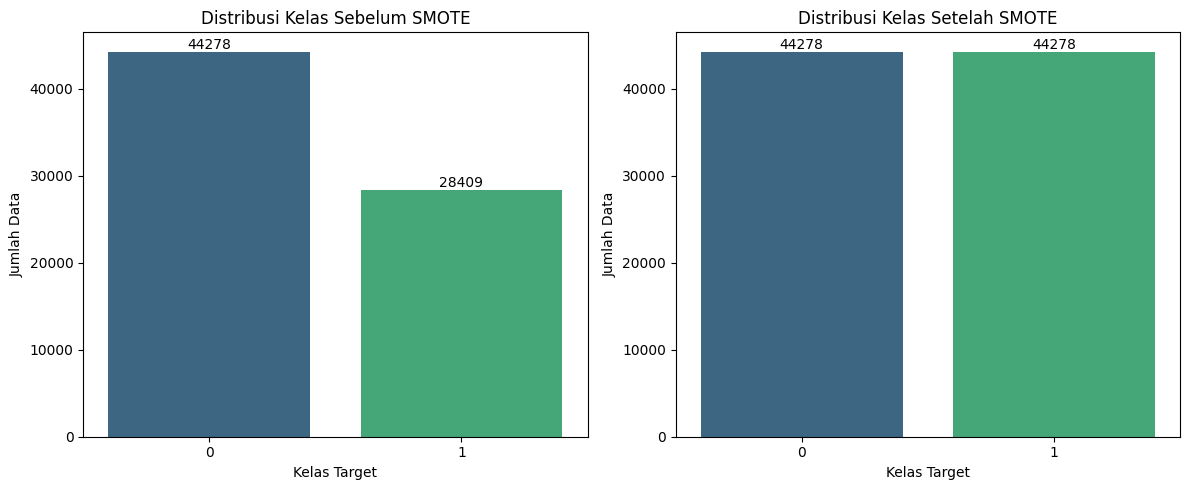

In [26]:

y_train_series = pd.Series(y_train)
y_train_smote_series = pd.Series(y_train_smote)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train_series, ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Kelas Sebelum SMOTE')
axes[0].set_xlabel('Kelas Target')
axes[0].set_ylabel('Jumlah Data')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom')

sns.countplot(x=y_train_smote_series, ax=axes[1], palette='viridis')
axes[1].set_title('Distribusi Kelas Setelah SMOTE')
axes[1].set_xlabel('Kelas Target')
axes[1].set_ylabel('Jumlah Data')

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [27]:
Classifier_accuracy = []

## Pencarian Model

#### SVM Classifier

=== Hasil Evaluasi Model SVM (dengan SMOTE) ===
Akurasi   : 97.55%
Presisi   : 95.58%
Recall    : 98.24%
F1-Score  : 96.89%
-----------------------------------------------


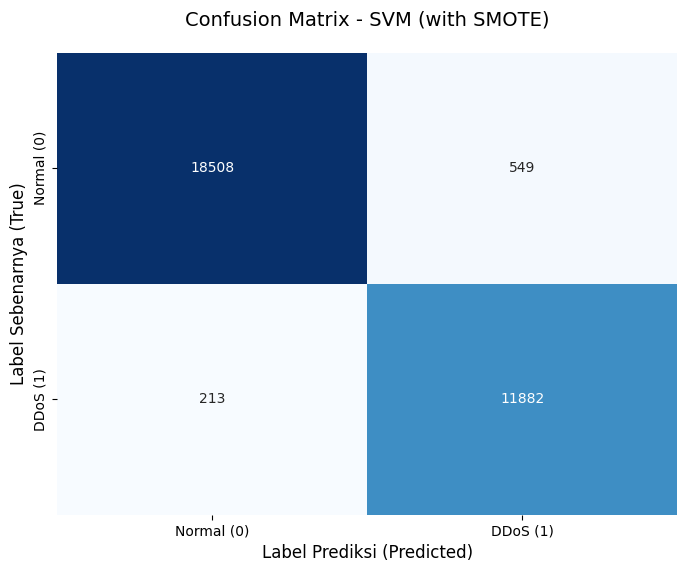

In [28]:
# 1. Latih model SVM menggunakan data yang sudah diseimbangkan (SMOTE)
svc_clf = SVC()
svc_clf.fit(X_train_smote, y_train_smote)

# 2. Lakukan prediksi pada data testing asli (X_test)
y_pred = svc_clf.predict(X_test)

# 3. Hitung Metrik Evaluasi secara individu
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Pastikan list Classifier_accuracy sudah didefinisikan sebelumnya
Classifier_accuracy.append(accuracy * 100)

# Menampilkan hasil evaluasi dengan rapi
print("=== Hasil Evaluasi Model SVM (dengan SMOTE) ===")
print("Akurasi   : {:.2f}%".format(accuracy * 100))
print("Presisi   : {:.2f}%".format(precision * 100))
print("Recall    : {:.2f}%".format(recall * 100))
print("F1-Score  : {:.2f}%".format(f1 * 100))
print("-" * 47)

# 4. Membuat dan Menampilkan Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
# Heatmap untuk visualisasi matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'DDoS (1)'],
            yticklabels=['Normal (0)', 'DDoS (1)'])

plt.title('Confusion Matrix - SVM (with SMOTE)', pad=20, fontsize=14)
plt.ylabel('Label Sebenarnya (True)', fontsize=12)
plt.xlabel('Label Prediksi (Predicted)', fontsize=12)
plt.show()

### Logistic Regression

=== Hasil Evaluasi Model Logistic Regression (dengan SMOTE) ===
Akurasi   : 82.54%
Presisi   : 74.96%
Recall    : 82.65%
F1-Score  : 78.62%
---------------------------------------------------------------


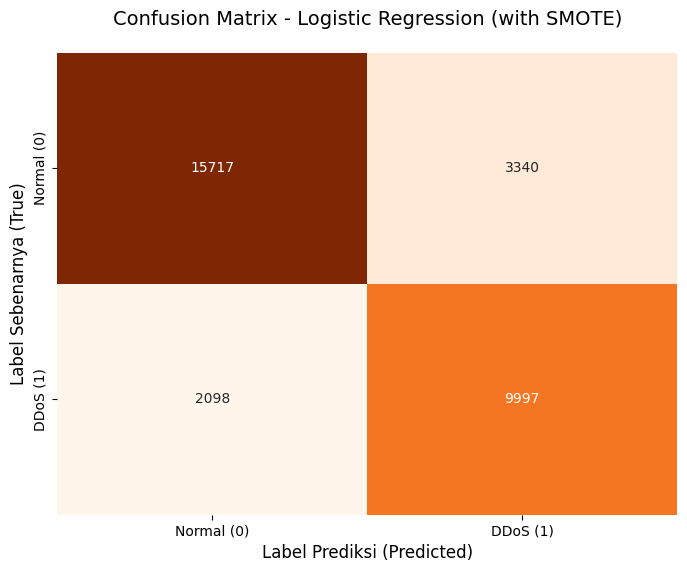

In [29]:
# MODEL: LOGISTIC REGRESSION
# 1. Latih model Logistic Regression menggunakan data yang sudah diseimbangkan (SMOTE)
logreg_clf = LogisticRegression(max_iter=1000, random_state=42)
logreg_clf.fit(X_train_smote, y_train_smote)

# 2. Lakukan prediksi pada data testing asli (X_test)
y_pred_logreg = logreg_clf.predict(X_test)

# 3. Hitung Metrik Evaluasi secara individu
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

# Menyimpan akurasi ke dalam list (pastikan Classifier_accuracy sudah didefinisikan)
Classifier_accuracy.append(accuracy_logreg * 100)

# Menampilkan hasil evaluasi dengan rapi
print("=== Hasil Evaluasi Model Logistic Regression (dengan SMOTE) ===")
print("Akurasi   : {:.2f}%".format(accuracy_logreg * 100))
print("Presisi   : {:.2f}%".format(precision_logreg * 100))
print("Recall    : {:.2f}%".format(recall_logreg * 100))
print("F1-Score  : {:.2f}%".format(f1_logreg * 100))
print("-" * 63)

# 4. Membuat dan Menampilkan Visualisasi Confusion Matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(8, 6))
# Heatmap untuk visualisasi matrix
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Normal (0)', 'DDoS (1)'],
            yticklabels=['Normal (0)', 'DDoS (1)'])

plt.title('Confusion Matrix - Logistic Regression (with SMOTE)', pad=20, fontsize=14)
plt.ylabel('Label Sebenarnya (True)', fontsize=12)
plt.xlabel('Label Prediksi (Predicted)', fontsize=12)
plt.show()

### XgBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:06:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Hasil Evaluasi Model XGBoost (dengan SMOTE) ===
Akurasi   : 100.00%
Presisi   : 100.00%
Recall    : 100.00%
F1-Score  : 100.00%
---------------------------------------------------


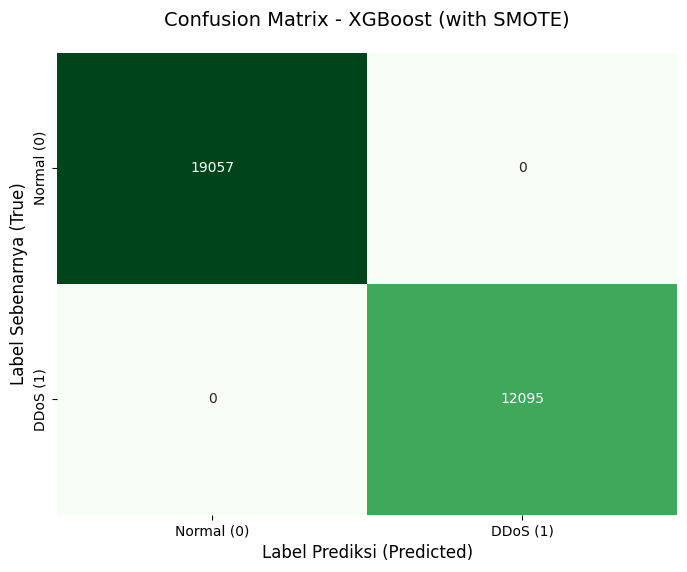

In [30]:
# MODEL: XGBOOST
# 1. Latih model XGBoost menggunakan data yang sudah diseimbangkan (SMOTE)
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_smote, y_train_smote)

# 2. Lakukan prediksi pada data testing asli (X_test)
y_pred_xgb = xgb_clf.predict(X_test)

# 3. Hitung Metrik Evaluasi secara individu
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Menyimpan akurasi ke dalam list
Classifier_accuracy.append(accuracy_xgb * 100)

# Menampilkan hasil evaluasi dengan rapi
print("=== Hasil Evaluasi Model XGBoost (dengan SMOTE) ===")
print("Akurasi   : {:.2f}%".format(accuracy_xgb * 100))
print("Presisi   : {:.2f}%".format(precision_xgb * 100))
print("Recall    : {:.2f}%".format(recall_xgb * 100))
print("F1-Score  : {:.2f}%".format(f1_xgb * 100))
print("-" * 51)

# 4. Membuat dan Menampilkan Visualisasi Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
# Heatmap untuk visualisasi matrix
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Normal (0)', 'DDoS (1)'],
            yticklabels=['Normal (0)', 'DDoS (1)'])

plt.title('Confusion Matrix - XGBoost (with SMOTE)', pad=20, fontsize=14)
plt.ylabel('Label Sebenarnya (True)', fontsize=12)
plt.xlabel('Label Prediksi (Predicted)', fontsize=12)
plt.show()

## Pengecekan Overfiting Setiap Model

In [31]:
print("\n" + "="*55)
print("=== ANALISIS OVERFITTING / GENERALISASI MODEL ===")
print("="*55)

# Fungsi bantuan untuk mencetak hasil dengan rapi
def print_overfitting_status(model_name, acc_train, acc_test):
    gap = acc_train - acc_test
    print(f"\nModel: {model_name}")
    print(f"Akurasi Data Training : {acc_train:.2f}%")
    print(f"Akurasi Data Testing  : {acc_test:.2f}%")
    print(f"Selisih (Gap)         : {gap:.2f}%")

    # Aturan sederhana: Jika selisih > 5%, indikasi overfitting
    if gap > 5.0:
        print("Status : Indikasi OVERFITTING (Model menghafal data training)")
    elif gap < -2.0:
        print("Status : Indikasi UNDERFITTING (Periksa kembali datanya)")
    else:
        print("Status : GOOD FIT (Model sudah optimal)")

# 1. Lakukan Prediksi menggunakan Data Training (SMOTE)
y_pred_train_svm = svc_clf.predict(X_train_smote)
y_pred_train_logreg = logreg_clf.predict(X_train_smote)
y_pred_train_xgb = xgb_clf.predict(X_train_smote)

# 2. Hitung Akurasi Training
acc_train_svm = accuracy_score(y_train_smote, y_pred_train_svm) * 100
acc_train_logreg = accuracy_score(y_train_smote, y_pred_train_logreg) * 100
acc_train_xgb = accuracy_score(y_train_smote, y_pred_train_xgb) * 100

# 3. Ambil Akurasi Testing dari variabel yang sudah Anda definisikan sebelumnya
acc_test_svm = accuracy * 100
acc_test_logreg = accuracy_logreg * 100
acc_test_xgb = accuracy_xgb * 100

# Hasil
print_overfitting_status("SVM", acc_train_svm, acc_test_svm)
print_overfitting_status("Logistic Regression", acc_train_logreg, acc_test_logreg)
print_overfitting_status("XGBoost", acc_train_xgb, acc_test_xgb)
print("\n" + "="*55)


=== ANALISIS OVERFITTING / GENERALISASI MODEL ===

Model: SVM
Akurasi Data Training : 97.77%
Akurasi Data Testing  : 97.55%
Selisih (Gap)         : 0.22%
Status : GOOD FIT (Model sudah optimal)

Model: Logistic Regression
Akurasi Data Training : 82.77%
Akurasi Data Testing  : 82.54%
Selisih (Gap)         : 0.22%
Status : GOOD FIT (Model sudah optimal)

Model: XGBoost
Akurasi Data Training : 100.00%
Akurasi Data Testing  : 100.00%
Selisih (Gap)         : 0.00%
Status : GOOD FIT (Model sudah optimal)



## Hasil ROC

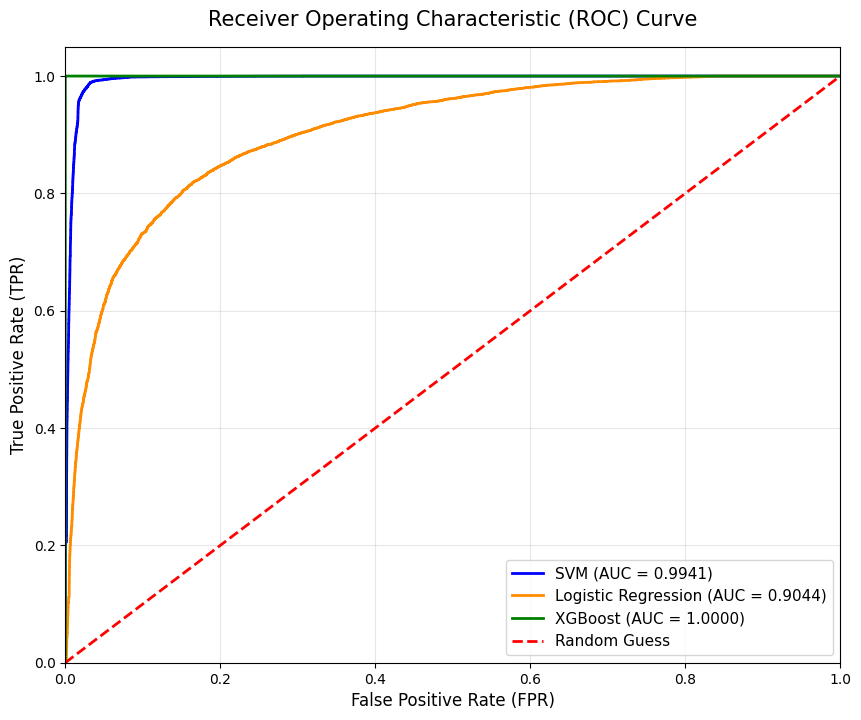

In [32]:
# 1. Dapatkan nilai probabilitas / skor prediksi untuk masing-masing model

y_score_svm = svc_clf.decision_function(X_test)
y_score_logreg = logreg_clf.predict_proba(X_test)[:, 1]
y_score_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# 2. Hitung False Positive Rate (FPR), True Positive Rate (TPR), dan AUC
# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Logistic Regression
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_score_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_score_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# 3. Buat Visualisasi ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr_svm, tpr_svm, color='blue', lw=2,
         label='SVM (AUC = %0.4f)' % roc_auc_svm)
plt.plot(fpr_logreg, tpr_logreg, color='darkorange', lw=2,
         label='Logistic Regression (AUC = %0.4f)' % roc_auc_logreg)
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2,
         label='XGBoost (AUC = %0.4f)' % roc_auc_xgb)

plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')

# Pengaturan tata letak plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=15, pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

# Tampilkan grafik
plt.show()

##Grafik Perbandingan Model

Berdasarkan grafik, model terbaik adalah **XGBoost** dengan akurasi 100.00%


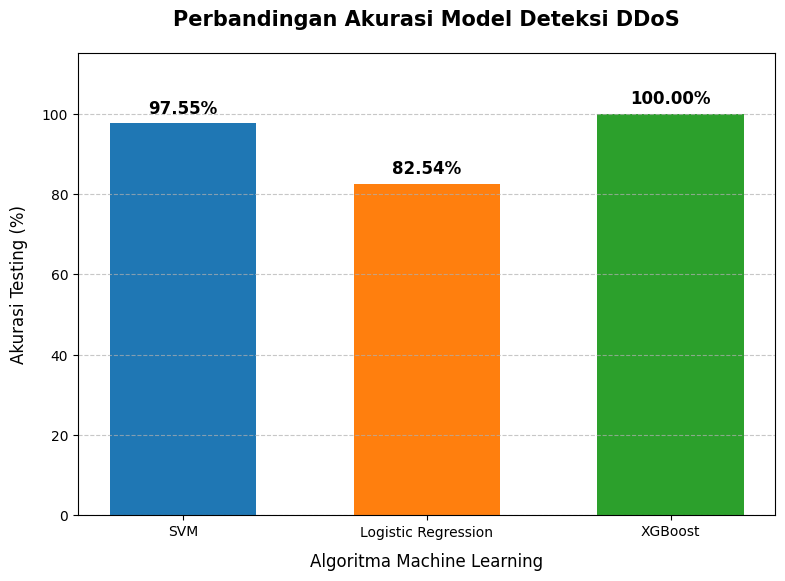

In [33]:
# 1. Menyiapkan data untuk grafik
model_names = ['SVM', 'Logistic Regression', 'XGBoost']
model_accuracies = [acc_test_svm, acc_test_logreg, acc_test_xgb]

# 2. Menentukan warna yang berbeda untuk masing-masing model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# 3. Membuat grafik batang
plt.figure(figsize=(9, 6))
bars = plt.bar(model_names, model_accuracies, color=colors, width=0.6)

# 4. Menambahkan label persentase tepat di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5,
             f'{yval:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# 5. Pengaturan tata letak dan estetika grafik
plt.title('Perbandingan Akurasi Model Deteksi DDoS', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Algoritma Machine Learning', fontsize=12, labelpad=10)
plt.ylabel('Akurasi Testing (%)', fontsize=12, labelpad=10)
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Menampilkan akurasi
best_idx = np.argmax(model_accuracies)
best_model_name = model_names[best_idx]
max_acc = model_accuracies[best_idx]
print(f"Berdasarkan grafik, model terbaik adalah **{best_model_name}** dengan akurasi {max_acc:.2f}%")

plt.show()

##Menyimpan Model Terbaik

In [34]:
import joblib

# 1. Menyimpan Scaler
# Menggunakan objek MinMaxScaler 'ms' yang sudah di-fit sebelumnya
joblib.dump(ms, 'scaler_ddos.pkl')
print("✅ Scaler berhasil disimpan sebagai 'scaler_ddos.pkl'")
print("-" * 50)

# 2. Mengumpulkan model dan akurasi yang sudah dihitung sebelumnya
models_info = [
    {"name": "SVM", "model": svc_clf, "accuracy": accuracy},
    {"name": "Logistic Regression", "model": logreg_clf, "accuracy": accuracy_logreg},
    {"name": "XGBoost", "model": xgb_clf, "accuracy": accuracy_xgb}
]

# 3. Mencari model dengan akurasi tertinggi
best_model_info = max(models_info, key=lambda x: x["accuracy"])

best_model_name = best_model_info["name"]
best_model = best_model_info["model"]
best_accuracy = best_model_info["accuracy"]

print(f"🏆 Model terbaik adalah {best_model_name} dengan akurasi {best_accuracy*100:.2f}%")

# 4. Menyimpan Model Terbaik
joblib.dump(best_model, 'best_model_ddos.pkl')
print(f"✅ Model {best_model_name} berhasil disimpan sebagai 'best_model_ddos.pkl'")

✅ Scaler berhasil disimpan sebagai 'scaler_ddos.pkl'
--------------------------------------------------
🏆 Model terbaik adalah XGBoost dengan akurasi 100.00%
✅ Model XGBoost berhasil disimpan sebagai 'best_model_ddos.pkl'
